<a href="https://colab.research.google.com/github/miriamformaro/ProgettoQuantum/blob/main/ProgettoQuantumC_FormaroMuglia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto Quantum Computing
## Classificazione degli studenti con classificatori classici e VQC

**Traccia:** uso di VQE o altri algoritmi variazionali per problemi di classificazione.

Viene costruito un problema di classificazione binaria sul dataset student_mat.csv:

- `0` = studente non promosso, cioè `G3 < 10`
- `1` = studente promosso, cioè `G3 >= 10`

La struttura del lavoro è:

1. caricamento e preprocessing del dataset;
2. classificazione classica con **Decision Tree** e **Random Forest**;
3. costruzione di circuiti quantistici con **ZFeatureMap** ed **EfficientSU2**;
4. confronto del VQC con **2, 3 e 4 feature**;
5. confronto tra due ottimizzatori classici: **COBYLA** e **COBYQA**;
6. valutazione finale anche su simulatore con rumore.

Le feature usate nel modello quantistico sono:

- 2 feature: `failures`, `absences`
- 3 feature: `failures`, `absences`, `studytime`
- 4 feature: `failures`, `absences`, `studytime`, `higher`

Per rendere il confronto più coerente, anche Decision Tree e Random Forest vengono testati sulle stesse combinazioni di feature.


## 1. Installazione delle librerie


In [1]:
!pip -q install scikit-learn imbalanced-learn qiskit qiskit-aer pylatexenc "scipy>=1.14"
!pip install qiskit-ibm-runtime qiskit-aer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 13.1 MB/s eta 0:00:00


## 2. Import delle librerie

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE, SMOTENC

from scipy.optimize import minimize

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import ZFeatureMap, EfficientSU2
from qiskit.primitives import StatevectorSampler
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 3. Caricamento del dataset




In [3]:
DATASET_PATH = "student-mat.csv"

df = pd.read_csv(DATASET_PATH, sep=";")

print("File caricato:", DATASET_PATH)
print("Dimensioni del dataset:", df.shape)
display(df.head())


File caricato: student-mat.csv
Dimensioni del dataset: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 4. Preprocessing

Per trasformare il problema in classificazione binaria, usiamo il voto finale `G3`.

Inoltre convertiamo `higher`, che nel dataset è categorica (`yes`/`no`), in numerica:

- `yes` → 1
- `no` → 0

Non usiamo `G1` e `G2` nei modelli principali perché sono voti intermedi molto vicini al target finale `G3`: includerli renderebbe il problema classico molto più facile e meno confrontabile con i circuiti costruiti sulle feature scelte.

In [4]:
def preprocess_student_dataset(df):
    df = df.copy()

    # Conversione dei voti in formato numerico
    for col in ["G1", "G2", "G3"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Target binario: 1 = promosso, 0 = non promosso
    df["passed"] = (df["G3"] >= 10).astype(int)

    # Feature categorica usata nel circuito a 4 qubit
    df["higher"] = df["higher"].map({"yes": 1, "no": 0})

    needed_cols = ["failures", "absences", "studytime", "higher", "G3", "passed"]
    df = df.dropna(subset=needed_cols).reset_index(drop=True)

    return df

student_df = preprocess_student_dataset(df)

FEATURE_SETS = {
    "2 feature": ["failures", "absences"],
    "3 feature": ["failures", "absences", "studytime"],
    "4 feature": ["failures", "absences", "studytime", "higher"],
}

TARGET = "passed"
CLASS_NAMES = ["non promosso", "promosso"]

print("Dimensioni dopo preprocessing:", student_df.shape)
print("Distribuzione del target:")
print(student_df[TARGET].value_counts().sort_index())
display(student_df[["failures", "absences", "studytime", "higher", "G3", "passed"]].head())

Dimensioni dopo preprocessing: (395, 34)
Distribuzione del target:
passed
0    130
1    265
Name: count, dtype: int64


,failures,absences,studytime,higher,G3,passed
0,0,6,2,1,6,0
1,0,4,2,1,6,0
2,3,10,2,1,10,1
3,0,2,3,1,15,1
4,0,4,2,1,10,1


### Criterio di selezione delle feature

Le feature sono state selezionate seguendo un criterio sia interpretativo sia computazionale. Dal punto di vista interpretativo sono state scelte variabili legate in modo comprensibile al rendimento dello studente: `failures`, cioè il numero di insuccessi precedenti; `absences`, cioè il numero di assenze; `studytime`, cioè il tempo di studio settimanale; e `higher`, cioè l'intenzione di proseguire gli studi.

Dal punto di vista quantistico, la scelta è stata mantenuta volutamente limitata perché in questa implementazione ogni feature viene associata a un qubit. In questo modo si possono costruire e confrontare circuiti a 2, 3 e 4 qubit, osservando come cambia il comportamento del VQC all'aumentare delle feature classiche codificate.

Non sono state usate come feature principali le variabili `G1` e `G2`, perché rappresentano voti intermedi molto vicini al voto finale `G3`. Inserirle avrebbe probabilmente aumentato le metriche, ma avrebbe reso il problema meno interessante e meno coerente con l'obiettivo del progetto.

## 5. Esplorazione rapida del dataset


,failures,absences,studytime,higher,G3,passed
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,0.334177,5.708861,2.035443,0.949367,10.415190,0.670886
std,0.743651,8.003096,0.839240,0.219525,4.581443,0.470487
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,1.000000,8.000000,0.000000
50%,0.000000,4.000000,2.000000,1.000000,11.000000,1.000000
75%,0.000000,8.000000,2.000000,1.000000,14.000000,1.000000
max,3.000000,75.000000,4.000000,1.000000,20.000000,1.000000


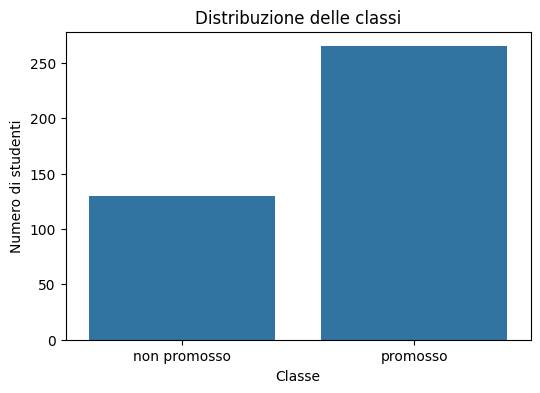

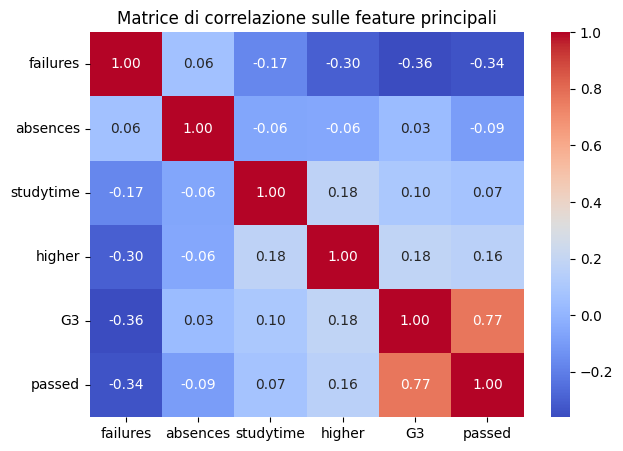

In [5]:
selected_cols = ["failures", "absences", "studytime", "higher", "G3", "passed"]

display(student_df[selected_cols].describe())

plt.figure(figsize=(6, 4))
sns.countplot(data=student_df, x=TARGET)
plt.xticks([0, 1], CLASS_NAMES)
plt.title("Distribuzione delle classi")
plt.xlabel("Classe")
plt.ylabel("Numero di studenti")
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(student_df[selected_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice di correlazione sulle feature principali")
plt.show()

# Parte I - Classificatori classici

Utilizziamo due classificatori:

1. **Decision Tree**
2. **Random Forest**

I modelli vengono testati sulle stesse combinazioni di feature che saranno poi usate nel circuito quantistico.

## 6. Funzioni di valutazione classica

Il bilanciamento viene applicato esclusivamente al training set: usiamo **SMOTE** per i gruppi composti da sole feature numeriche e **SMOTENC** quando è presente `higher`, trattata come variabile categorica binaria. Poiché il training set viene già bilanciato tramite oversampling, i classificatori non applicano un ulteriore `class_weight`.


In [6]:
CLASSICAL_MODELS = {
    # Il training set è già bilanciato da SMOTE/SMOTENC,
    # quindi non è necessario applicare anche class_weight.
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=5,
    ),
    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200,
        max_depth=5,
    ),
}


def evaluate_classical_models(df, feature_names, feature_set_name):
    X = df[feature_names]
    y = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    print(f"{feature_set_name} - training set: {X_train.shape[0]} esempi, test set: {X_test.shape[0]} esempi")

    # Imputazione calcolata solo sul training set
    imputer = SimpleImputer(strategy="median")
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # SMOTE/SMOTENC solo sul training set
    # Se tra le feature è presente higher, la trattiamo come variabile categorica binaria.
    if "higher" in feature_names:
        higher_index = feature_names.index("higher")
        smote = SMOTENC(
            categorical_features=[higher_index],
            random_state=RANDOM_STATE,
            k_neighbors=3,
        )
    else:
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)

    X_train_bal, y_train_bal = smote.fit_resample(X_train_imp, y_train)

    results = []
    trained_models = {}

    for model_name, model in CLASSICAL_MODELS.items():
        model.fit(X_train_bal, y_train_bal)
        y_pred = model.predict(X_test_imp)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        results.append({
            "feature_set": feature_set_name,
            "n_feature": len(feature_names),
            "model": model_name,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
        })

        trained_models[(feature_set_name, model_name)] = {
            "model": model,
            "imputer": imputer,
            "X_test": X_test_imp,
            "y_test": y_test,
            "y_pred": y_pred,
            "feature_names": feature_names,
        }

        print("=" * 80)
        print(f"{model_name} - {feature_set_name}: {feature_names}")
        print("Accuracy:", round(acc, 4))
        print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
        )
        plt.title(f"Matrice di confusione - {model_name} - {feature_set_name}")
        plt.xlabel("Predetto")
        plt.ylabel("Reale")
        plt.tight_layout()
        plt.show()

    return results, trained_models

## 7. Addestramento e confronto dei modelli classici

2 feature - training set: 276 esempi, test set: 119 esempi
Decision Tree - 2 feature: ['failures', 'absences']
Accuracy: 0.6723
              precision    recall  f1-score   support

non promosso       0.50      0.31      0.38        39
    promosso       0.72      0.85      0.78        80

    accuracy                           0.67       119
   macro avg       0.61      0.58      0.58       119
weighted avg       0.65      0.67      0.65       119



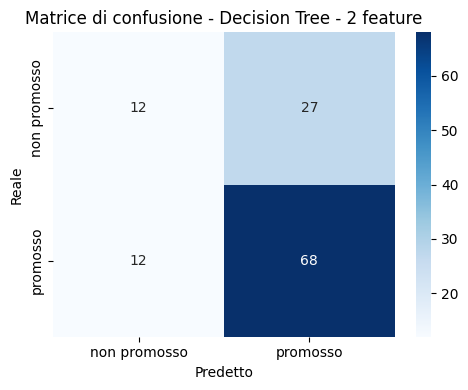

Random Forest - 2 feature: ['failures', 'absences']
Accuracy: 0.6807
              precision    recall  f1-score   support

non promosso       0.52      0.33      0.41        39
    promosso       0.72      0.85      0.78        80

    accuracy                           0.68       119
   macro avg       0.62      0.59      0.59       119
weighted avg       0.66      0.68      0.66       119



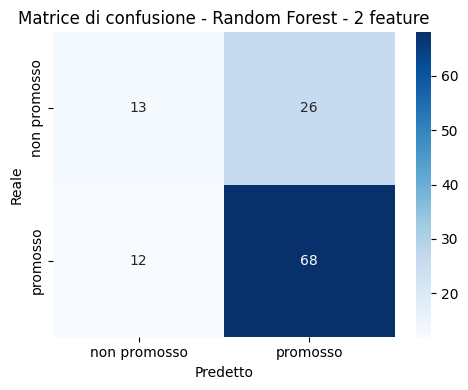

3 feature - training set: 276 esempi, test set: 119 esempi
Decision Tree - 3 feature: ['failures', 'absences', 'studytime']
Accuracy: 0.5966
              precision    recall  f1-score   support

non promosso       0.37      0.33      0.35        39
    promosso       0.69      0.72      0.71        80

    accuracy                           0.60       119
   macro avg       0.53      0.53      0.53       119
weighted avg       0.59      0.60      0.59       119



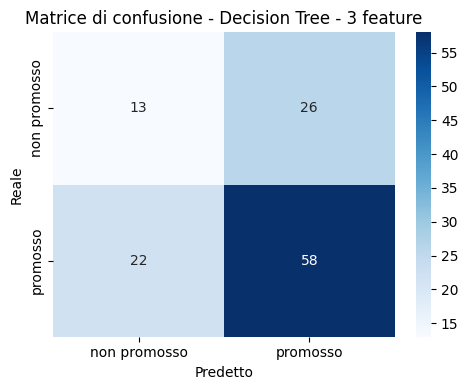

Random Forest - 3 feature: ['failures', 'absences', 'studytime']
Accuracy: 0.5966
              precision    recall  f1-score   support

non promosso       0.38      0.36      0.37        39
    promosso       0.70      0.71      0.70        80

    accuracy                           0.60       119
   macro avg       0.54      0.54      0.54       119
weighted avg       0.59      0.60      0.59       119



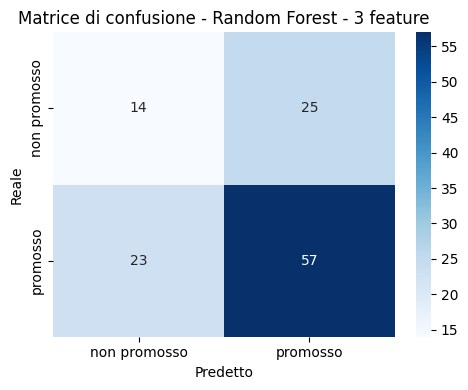

4 feature - training set: 276 esempi, test set: 119 esempi
Decision Tree - 4 feature: ['failures', 'absences', 'studytime', 'higher']
Accuracy: 0.605
              precision    recall  f1-score   support

non promosso       0.38      0.31      0.34        39
    promosso       0.69      0.75      0.72        80

    accuracy                           0.61       119
   macro avg       0.53      0.53      0.53       119
weighted avg       0.59      0.61      0.59       119



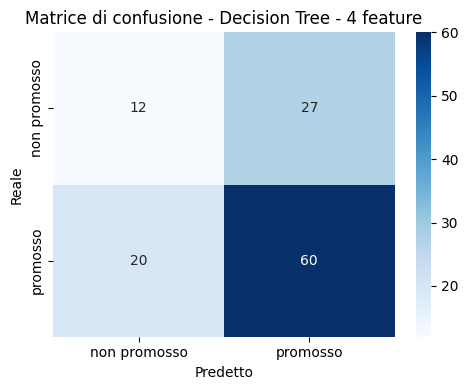

Random Forest - 4 feature: ['failures', 'absences', 'studytime', 'higher']
Accuracy: 0.6555
              precision    recall  f1-score   support

non promosso       0.47      0.38      0.42        39
    promosso       0.72      0.79      0.75        80

    accuracy                           0.66       119
   macro avg       0.60      0.59      0.59       119
weighted avg       0.64      0.66      0.65       119



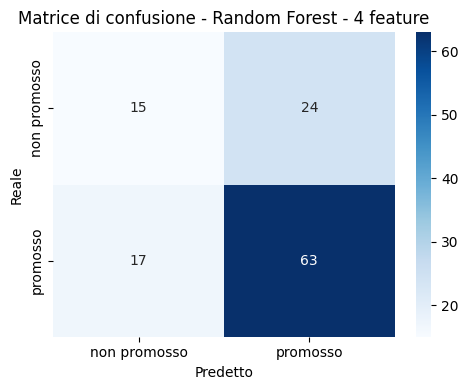

Risultati classici:


,feature_set,n_feature,model,accuracy,precision,recall,f1_score
0,2 feature,2,Decision Tree,0.672269,0.715789,0.8500,0.777143
1,2 feature,2,Random Forest,0.680672,0.723404,0.8500,0.781609
2,3 feature,3,Decision Tree,0.596639,0.690476,0.7250,0.707317
3,3 feature,3,Random Forest,0.596639,0.695122,0.7125,0.703704
4,4 feature,4,Decision Tree,0.605042,0.689655,0.7500,0.718563
5,4 feature,4,Random Forest,0.655462,0.724138,0.7875,0.754491


Accuracy a confronto:


feature_set,2 feature,3 feature,4 feature
model,,,
Decision Tree,0.672269,0.596639,0.605042
Random Forest,0.680672,0.596639,0.655462


In [7]:
all_classical_results = []
all_classical_models = {}

for feature_set_name, feature_names in FEATURE_SETS.items():
    results, trained = evaluate_classical_models(student_df, feature_names, feature_set_name)
    all_classical_results.extend(results)
    all_classical_models.update(trained)

classical_results_df = pd.DataFrame(all_classical_results)

print("Risultati classici:")
display(classical_results_df)

print("Accuracy a confronto:")
accuracy_table = classical_results_df.pivot_table(
    index="model",
    columns="feature_set",
    values="accuracy",
)
display(accuracy_table)

## 8. Visualizzazione del Decision Tree sulle 4 feature

Questa visualizzazione mostra in modo chiaro le regole decisionali apprese dal modello.

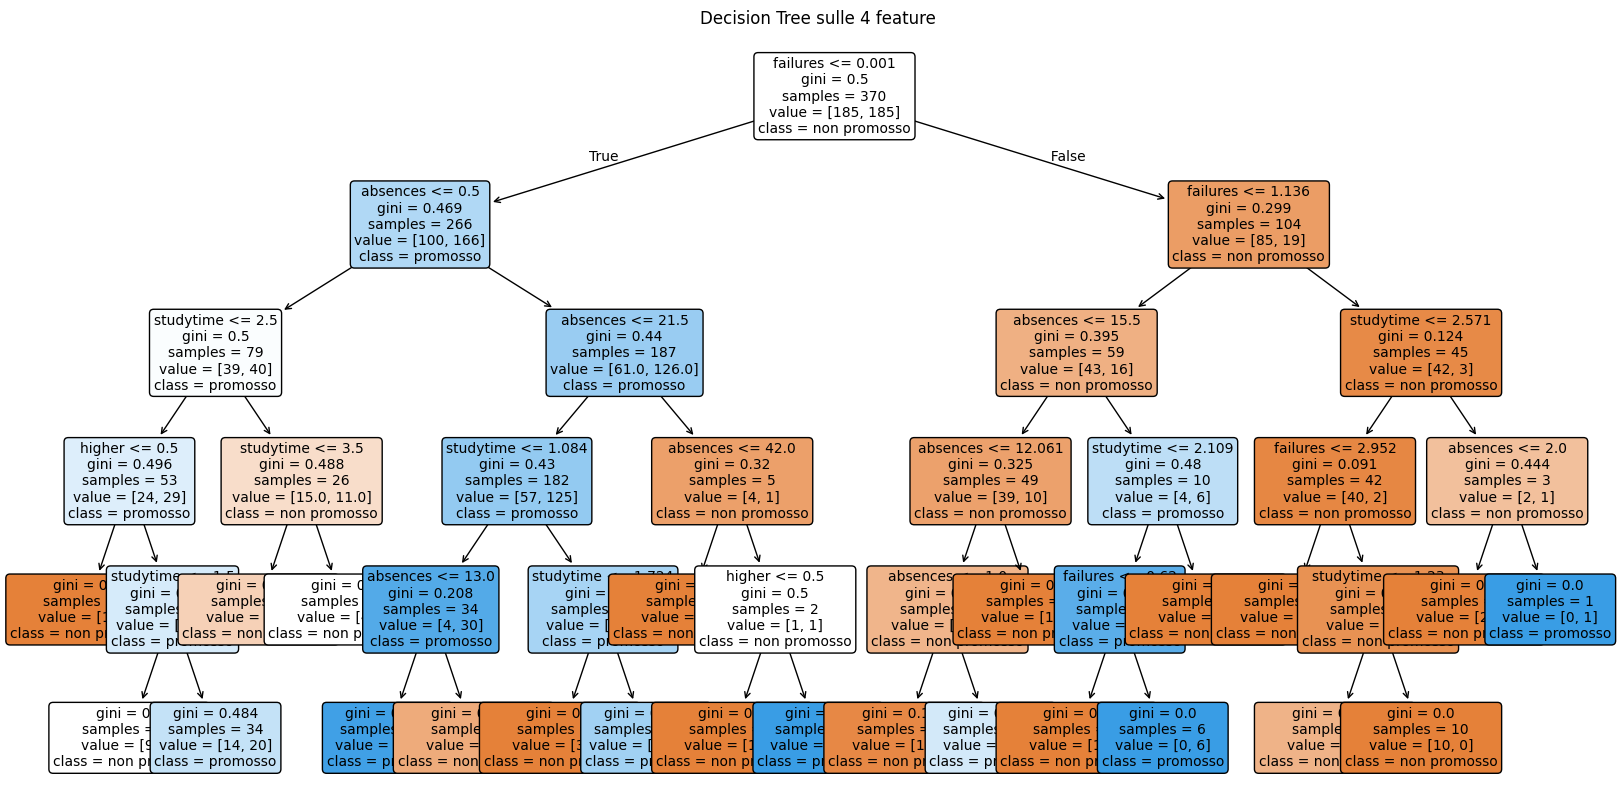

In [8]:
dt_info = all_classical_models[("4 feature", "Decision Tree")]
dt_model = dt_info["model"]

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=FEATURE_SETS["4 feature"],
    class_names=CLASS_NAMES,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree sulle 4 feature")
plt.show()

## 9. Importanza delle feature nella Random Forest

,feature,importance
0,failures,0.491410
1,absences,0.313201
2,studytime,0.161442
3,higher,0.033947


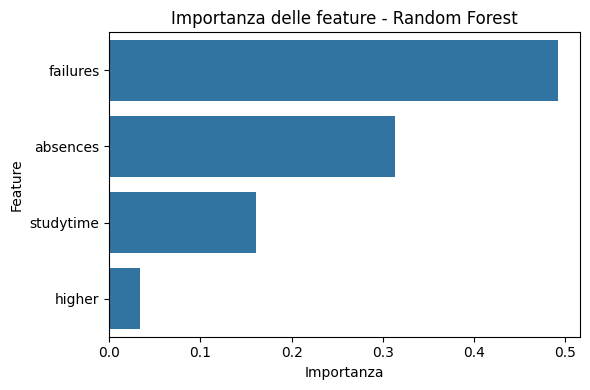

In [9]:
rf_info = all_classical_models[("4 feature", "Random Forest")]
rf_model = rf_info["model"]

feature_importances = pd.DataFrame({
    "feature": FEATURE_SETS["4 feature"],
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importances)

plt.figure(figsize=(6, 4))
sns.barplot(data=feature_importances, x="importance", y="feature")
plt.title("Importanza delle feature - Random Forest")
plt.xlabel("Importanza")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Parte II - Variational Quantum Classifier

In questa parte costruiamo un VQC.

La struttura è:

1. **ZFeatureMap**: codifica le feature classiche negli angoli del circuito;
2. **EfficientSU2**: ansatz parametrico, cioè la parte variazionale del circuito;
3. **StatevectorSampler**: simulazione ideale del circuito;
4. **funzione di costo**: binary cross-entropy;
5. **ottimizzazione classica**: confronto tra COBYLA e COBYQA;
6. **simulazione rumorosa**: valutazione del circuito ottimizzato anche su un simulatore con rumore.

L'output viene interpretato tramite la **parità del bitstring**:

- bitstring con numero pari di `1` → classe 0
- bitstring con numero dispari di `1` → classe 1

Per motivi computazionali, il VQC viene addestrato su un sottoinsieme ridotto del dataset.


## 10. Normalizzazione per la ZFeatureMap

Le feature vengono portate nel range `[0, pi]`, perché nel circuito vengono usate come angoli.

La scelta di `[0, pi]` non è solo una normalizzazione numerica. In una feature map basata su rotazioni, usare `[0, 2*pi]` potrebbe creare ambiguità agli estremi, perché 0 e `2*pi` corrispondono a un giro completo e quindi a configurazioni equivalenti o molto simili. Con `[0, pi]` usiamo un intervallo angolare ampio, ma evitiamo di richiudere subito la periodicità completa della rotazione.

Una normalizzazione in `[0, 1]` sarebbe possibile, ma sfrutterebbe un intervallo angolare molto più piccolo. Per questo abbiamo scelto `[0, pi]`, che ci è sembrato un compromesso più adatto per codificare le feature nella ZFeatureMap.

La normalizzazione viene calcolata **solo sul training set** e poi applicata al test set.


In [10]:
def scale_vqc_after_split(X_train, X_test):

    # Le feature diventano angoli della ZFeatureMap.
    # Usiamo [0, pi] per evitare l'ambiguità periodica di un giro completo [0, 2*pi]
    # e per usare un intervallo più espressivo rispetto a [0, 1].
    scaler = MinMaxScaler(feature_range=(0, np.pi))

    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index,
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index,
    )

    return X_train_scaled, X_test_scaled, scaler


## 11. Funzioni quantistiche e di ottimizzazione

In [11]:
def circuit_instance(tupla, variational, feature_map, ansatz, ad_hoc_circuit):
    # Crea un contenitore (dizionario) per associare i nomi dei parametri ai numeri
    parameters = {}
    # Prendi i dati dello studente (tupla) e assegnali agli angoli della Feature Map
    for i, p in enumerate(feature_map.ordered_parameters):
        parameters[p] = tupla[i]

    # Prendi i pesi allenabili (variational) e assegnali ai parametri del circuito (Ansatz)
    for i, p in enumerate(ansatz.ordered_parameters):
        parameters[p] = variational[i]

    # "Congela" il circuito sostituendo i simboli con i numeri reali (i dati e i pesi)
    return ad_hoc_circuit.assign_parameters(parameters)


def interpreter(bitstring):
    # Conta quanti '1' sono presenti nella stringa di misura (es: '0101' -> peso 2)
    hamming_weight = sum(int(k) for k in list(bitstring))
    # Ritorna 0 se il numero di '1' è pari, 1 se è dispari (parità)
    return hamming_weight % 2

# serve a trasformare i risultati del computer quantistico in una probabilità che l'ottimizzatore può capire.
def label_probability(results):
    # Calcola il numero totale di esecuzioni (shots) effettuate dal simulatore
    shots = sum(results.values())
    # Prepara un dizionario dove accumuleremo le probabilità per la classe 0 e la classe 1
    probabilities = {0: 0, 1: 0}

    # Analizza ogni possibile risultato (bitstring) uscito dal circuito
    for bitstring, counts in results.items():
        # Usa l'interpreter (la funzione di parità) per capire a quale classe appartiene il bitstring
        label = interpreter(bitstring)
        # Somma la probabilità (conteggi / totale) alla classe corrispondente
        probabilities[label] += counts / shots

    # Restituisce la distribuzione di probabilità finale (es. {0: 0.2, 1: 0.8})
    return probabilities


# SIMULAZIONE IDEALE
def classification_probability(data, variational, feature_map, ansatz, ad_hoc_circuit):
    circuits = [
        circuit_instance(tupla, variational, feature_map, ansatz, ad_hoc_circuit)
        for tupla in data
    ]

    sampler = StatevectorSampler(seed=RANDOM_STATE)
    results = sampler.run(circuits).result()

    classifications = [
        label_probability(results[i].data.meas.get_counts())
        for i, _ in enumerate(circuits)
    ]

    return classifications


def cost_function(data, labels, variational, feature_map, ansatz, ad_hoc_circuit):
    classifications = classification_probability(
        data,
        variational,
        feature_map,
        ansatz,
        ad_hoc_circuit,
    )
    cost = log_loss(y_true=labels, y_pred=[[p[0], p[1]] for p in classifications])
    return cost


# SIMULAZIONE RUMOROSA
NOISY_SIMULATOR = None
NOISY_SIMULATOR_NAME = None


def get_noisy_simulator():
    """
    Crea un simulatore rumoroso leggero e riproducibile.
    Il modello scelto è depolarizzante: introduce una probabilità di errore sulle porte a uno e due qubit.
    """
    global NOISY_SIMULATOR, NOISY_SIMULATOR_NAME

    if NOISY_SIMULATOR is not None:
        return NOISY_SIMULATOR, NOISY_SIMULATOR_NAME

    noise_model = NoiseModel()
    one_qubit_error = depolarizing_error(0.002, 1)
    two_qubit_error = depolarizing_error(0.02, 2)

    noise_model.add_all_qubit_quantum_error(one_qubit_error, ["rx", "ry", "rz", "x", "sx", "h"])
    noise_model.add_all_qubit_quantum_error(two_qubit_error, ["cx"])

    NOISY_SIMULATOR = AerSimulator(noise_model=noise_model, seed_simulator=RANDOM_STATE)
    NOISY_SIMULATOR_NAME = "modello depolarizzante semplificato"
    return NOISY_SIMULATOR, NOISY_SIMULATOR_NAME

def classification_probability_with_noisy(data, variational, feature_map, ansatz, ad_hoc_circuit, shots=1024):
    circuits = [
        circuit_instance(tupla, variational, feature_map, ansatz, ad_hoc_circuit)
        for tupla in data
    ]

    sim, simulator_name = get_noisy_simulator()
    transpiled_qc = transpile(circuits, sim)
    results = sim.run(transpiled_qc, shots=shots, seed_simulator=RANDOM_STATE).result()

    counts = results.get_counts()
    if isinstance(counts, dict):
        counts = [counts]

    classifications = [label_probability(result) for result in counts]
    return classifications


def cost_function_with_noisy(data, labels, variational, feature_map, ansatz, ad_hoc_circuit):
    classifications = classification_probability_with_noisy(
        data,
        variational,
        feature_map,
        ansatz,
        ad_hoc_circuit,
    )
    cost = log_loss(y_true=labels, y_pred=[[p[0], p[1]] for p in classifications])
    return cost


## 12. Addestramento dei VQC

Per ogni gruppo di feature vengono costruiti e visualizzati più circuiti:

1. `ZFeatureMap`, usata per codificare i dati;
2. `EfficientSU2`, usato come ansatz variazionale;
3. circuito VQC completo senza misure;
4. circuito VQC completo con misure.

Per ogni circuito vengono poi testati due ottimizzatori:

- **COBYLA**
- **COBYQA**

L'addestramento viene fatto in simulazione ideale. Dopo l'addestramento, lo stesso circuito ottimizzato viene valutato anche su simulatore rumoroso.



 VQC - 2 feature: ['failures', 'absences'] (2 qubit)
Training VQC: 80 esempi
Test VQC: 40 esempi

1. FEATURE MAP - ZFeatureMap (2 qubit):


/tmp/ipykernel_1610/980406236.py:54: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(feature_dimension=num_features, reps=1)
/tmp/ipykernel_1610/980406236.py:55: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_features, reps=VQC_REPS_DEFAULT)


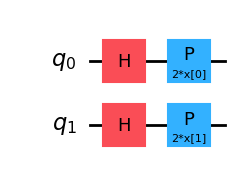


2. ANSATZ - EfficientSU2 (2 qubit):


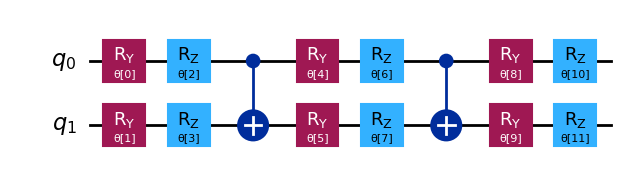


3. CIRCUITO VQC COMPLETO SENZA MISURE:


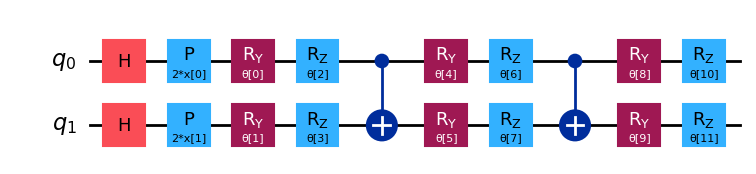


4. CIRCUITO VQC COMPLETO CON MISURE:


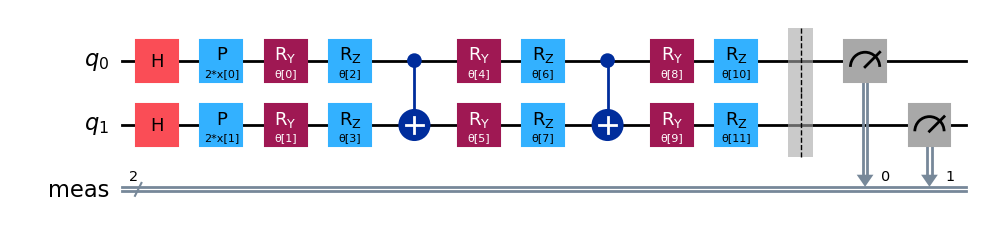


--------------------------------------------------------------------------------
Ottimizzazione con COBYLA - 2 feature
--------------------------------------------------------------------------------
loss_function: 0.706075 valutazione: 1
loss_function: 0.689012 valutazione: 10
loss_function: 0.700044 valutazione: 20
loss_function: 0.888183 valutazione: 30
loss_function: 0.57334 valutazione: 40
loss_function: 0.564306 valutazione: 50
loss_function: 0.565207 valutazione: 60
loss_function: 0.563817 valutazione: 70
loss_function: 0.563963 valutazione: 80
loss_function: 0.563868 valutazione: 90
loss_function: 0.563817 valutazione: 100
loss_function: 0.563817 valutazione: 110


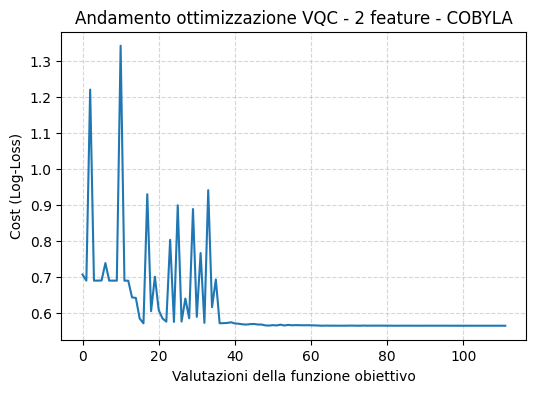


Risultati ideali - VQC con COBYLA - 2 feature
Accuracy: 0.7
              precision    recall  f1-score   support

non promosso       0.57      0.31      0.40        13
    promosso       0.73      0.89      0.80        27

    accuracy                           0.70        40
   macro avg       0.65      0.60      0.60        40
weighted avg       0.68      0.70      0.67        40



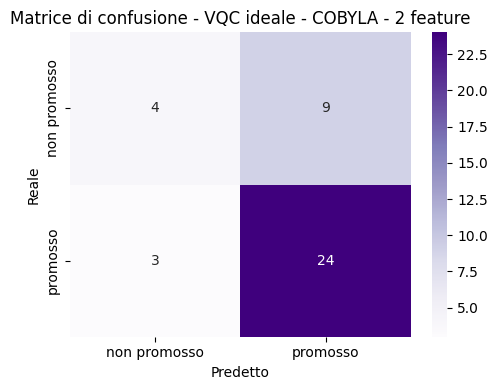


Risultati rumorosi - VQC con COBYLA - 2 feature
Simulatore rumoroso: modello depolarizzante semplificato
Accuracy: 0.7
              precision    recall  f1-score   support

non promosso       0.57      0.31      0.40        13
    promosso       0.73      0.89      0.80        27

    accuracy                           0.70        40
   macro avg       0.65      0.60      0.60        40
weighted avg       0.68      0.70      0.67        40



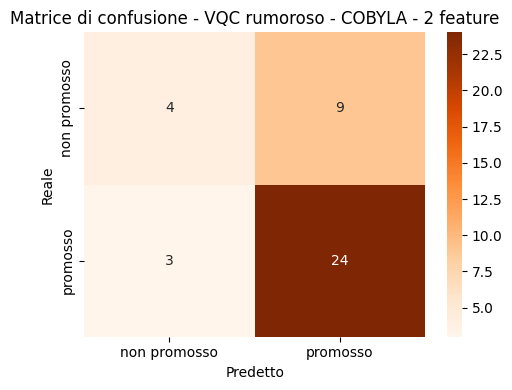


--------------------------------------------------------------------------------
Ottimizzazione con COBYQA - 2 feature
--------------------------------------------------------------------------------
loss_function: 0.706075 valutazione: 1
loss_function: 0.689182 valutazione: 10
loss_function: 0.706075 valutazione: 20
loss_function: 0.666557 valutazione: 30
loss_function: 0.589228 valutazione: 40
loss_function: 0.577749 valutazione: 50
loss_function: 0.571678 valutazione: 60
loss_function: 0.567582 valutazione: 70
loss_function: 0.566204 valutazione: 80
loss_function: 0.564877 valutazione: 90
loss_function: 0.563415 valutazione: 100
loss_function: 0.561186 valutazione: 110
loss_function: 0.559932 valutazione: 120
loss_function: 0.559093 valutazione: 130
loss_function: 0.558899 valutazione: 140
loss_function: 0.559047 valutazione: 150
loss_function: 0.558386 valutazione: 160
loss_function: 0.558306 valutazione: 170
loss_function: 0.558043 valutazione: 180
loss_function: 0.557898 valutaz

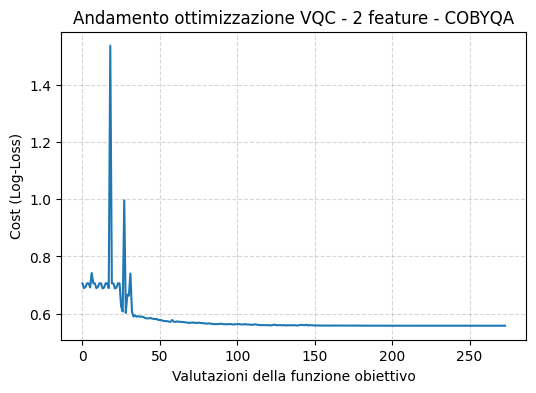


Risultati ideali - VQC con COBYQA - 2 feature
Accuracy: 0.7
              precision    recall  f1-score   support

non promosso       0.60      0.23      0.33        13
    promosso       0.71      0.93      0.81        27

    accuracy                           0.70        40
   macro avg       0.66      0.58      0.57        40
weighted avg       0.68      0.70      0.65        40



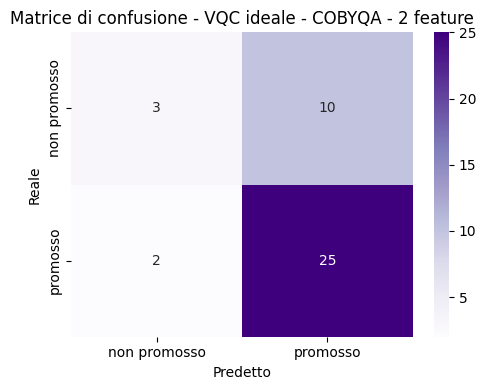


Risultati rumorosi - VQC con COBYQA - 2 feature
Simulatore rumoroso: modello depolarizzante semplificato
Accuracy: 0.7
              precision    recall  f1-score   support

non promosso       0.60      0.23      0.33        13
    promosso       0.71      0.93      0.81        27

    accuracy                           0.70        40
   macro avg       0.66      0.58      0.57        40
weighted avg       0.68      0.70      0.65        40



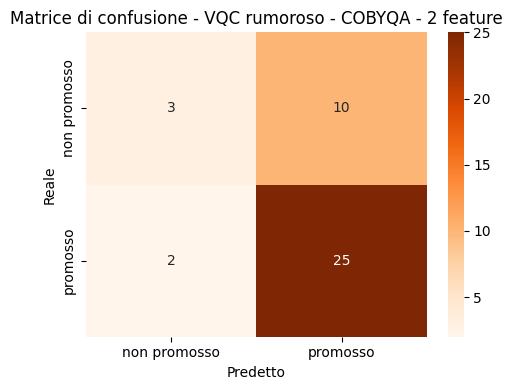


 VQC - 3 feature: ['failures', 'absences', 'studytime'] (3 qubit)
Training VQC: 80 esempi
Test VQC: 40 esempi

1. FEATURE MAP - ZFeatureMap (3 qubit):


/tmp/ipykernel_1610/980406236.py:54: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(feature_dimension=num_features, reps=1)
/tmp/ipykernel_1610/980406236.py:55: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_features, reps=VQC_REPS_DEFAULT)


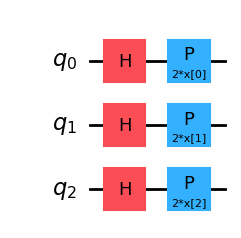


2. ANSATZ - EfficientSU2 (3 qubit):


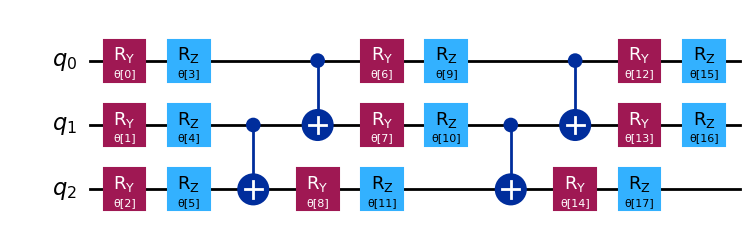


3. CIRCUITO VQC COMPLETO SENZA MISURE:


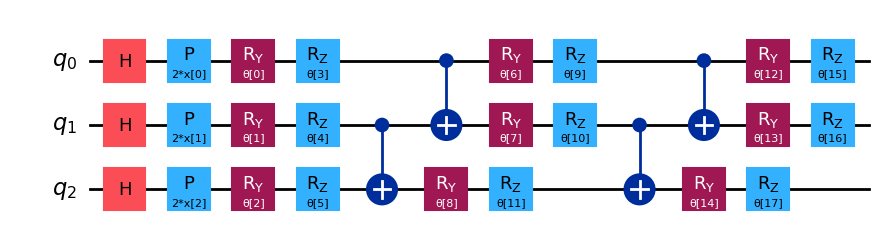


4. CIRCUITO VQC COMPLETO CON MISURE:


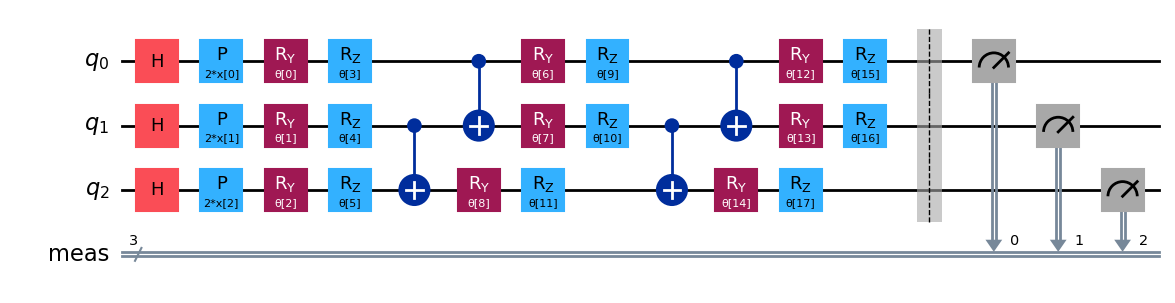


--------------------------------------------------------------------------------
Ottimizzazione con COBYLA - 3 feature
--------------------------------------------------------------------------------
loss_function: 0.699455 valutazione: 1
loss_function: 0.916765 valutazione: 10
loss_function: 1.003907 valutazione: 20
loss_function: 0.677384 valutazione: 30
loss_function: 0.679408 valutazione: 40
loss_function: 0.679733 valutazione: 50
loss_function: 0.673741 valutazione: 60
loss_function: 0.673448 valutazione: 70
loss_function: 0.673633 valutazione: 80
loss_function: 0.673385 valutazione: 90
loss_function: 0.673283 valutazione: 100
loss_function: 0.673554 valutazione: 110
loss_function: 0.673155 valutazione: 120
loss_function: 0.67326 valutazione: 130


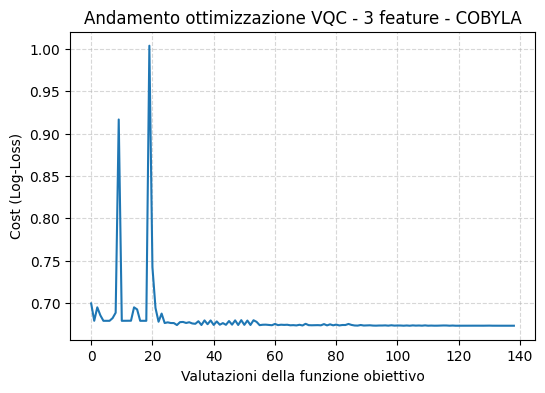


Risultati ideali - VQC con COBYLA - 3 feature
Accuracy: 0.55
              precision    recall  f1-score   support

non promosso       0.31      0.31      0.31        13
    promosso       0.67      0.67      0.67        27

    accuracy                           0.55        40
   macro avg       0.49      0.49      0.49        40
weighted avg       0.55      0.55      0.55        40



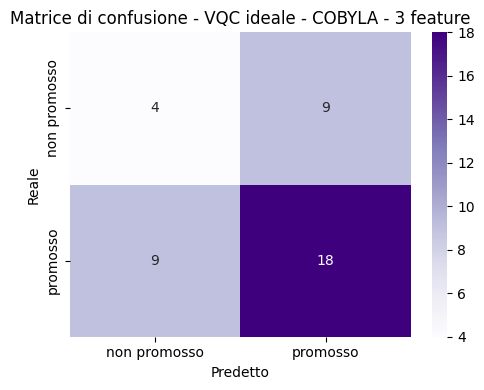


Risultati rumorosi - VQC con COBYLA - 3 feature
Simulatore rumoroso: modello depolarizzante semplificato
Accuracy: 0.5
              precision    recall  f1-score   support

non promosso       0.23      0.23      0.23        13
    promosso       0.63      0.63      0.63        27

    accuracy                           0.50        40
   macro avg       0.43      0.43      0.43        40
weighted avg       0.50      0.50      0.50        40



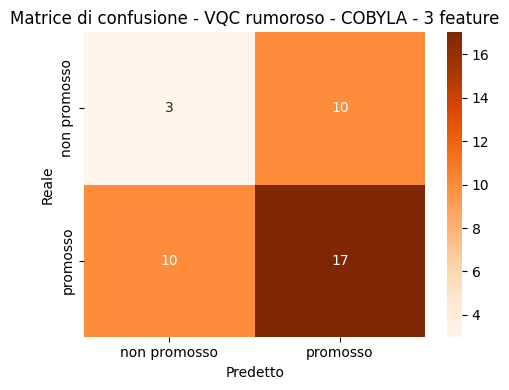


--------------------------------------------------------------------------------
Ottimizzazione con COBYQA - 3 feature
--------------------------------------------------------------------------------
loss_function: 0.699455 valutazione: 1
loss_function: 0.961671 valutazione: 10
loss_function: 0.703654 valutazione: 20
loss_function: 0.699455 valutazione: 30
loss_function: 0.679794 valutazione: 40
loss_function: 0.676651 valutazione: 50
loss_function: 0.66962 valutazione: 60
loss_function: 0.665009 valutazione: 70
loss_function: 0.655106 valutazione: 80
loss_function: 0.636534 valutazione: 90
loss_function: 0.618247 valutazione: 100
loss_function: 0.610797 valutazione: 110
loss_function: 0.60226 valutazione: 120
loss_function: 0.582844 valutazione: 130
loss_function: 0.566129 valutazione: 140
loss_function: 0.556024 valutazione: 150
loss_function: 0.546957 valutazione: 160
loss_function: 0.546104 valutazione: 170
loss_function: 0.545195 valutazione: 180
loss_function: 0.543448 valutazio

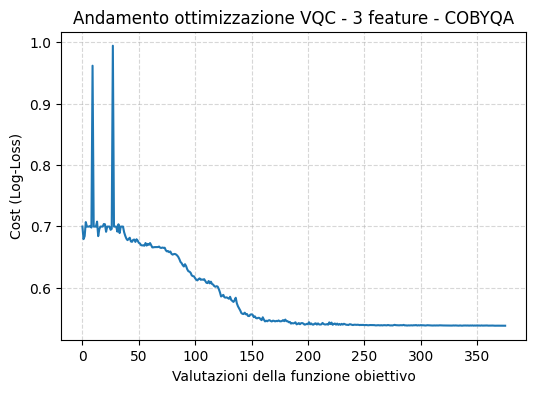


Risultati ideali - VQC con COBYQA - 3 feature
Accuracy: 0.675
              precision    recall  f1-score   support

non promosso       0.50      0.31      0.38        13
    promosso       0.72      0.85      0.78        27

    accuracy                           0.68        40
   macro avg       0.61      0.58      0.58        40
weighted avg       0.65      0.68      0.65        40



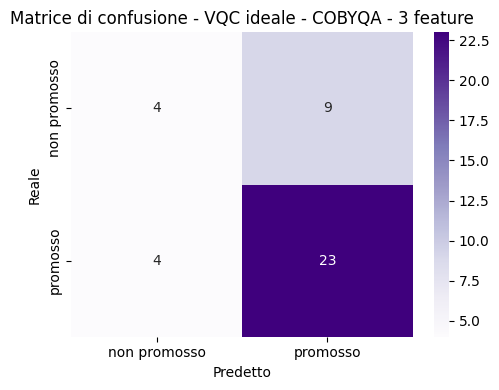


Risultati rumorosi - VQC con COBYQA - 3 feature
Simulatore rumoroso: modello depolarizzante semplificato
Accuracy: 0.675
              precision    recall  f1-score   support

non promosso       0.50      0.23      0.32        13
    promosso       0.71      0.89      0.79        27

    accuracy                           0.68        40
   macro avg       0.60      0.56      0.55        40
weighted avg       0.64      0.68      0.63        40



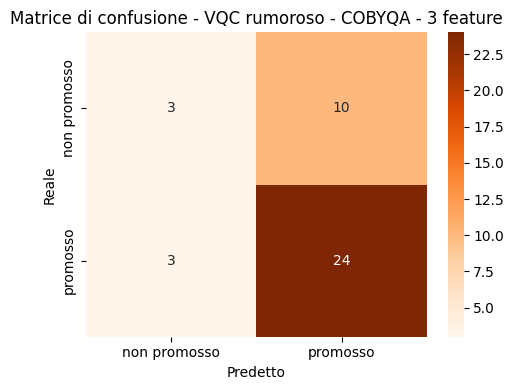


 VQC - 4 feature: ['failures', 'absences', 'studytime', 'higher'] (4 qubit)
Training VQC: 80 esempi
Test VQC: 40 esempi

1. FEATURE MAP - ZFeatureMap (4 qubit):


/tmp/ipykernel_1610/980406236.py:54: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(feature_dimension=num_features, reps=1)
/tmp/ipykernel_1610/980406236.py:55: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_features, reps=VQC_REPS_DEFAULT)


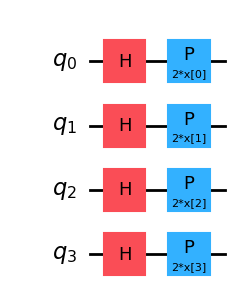


2. ANSATZ - EfficientSU2 (4 qubit):


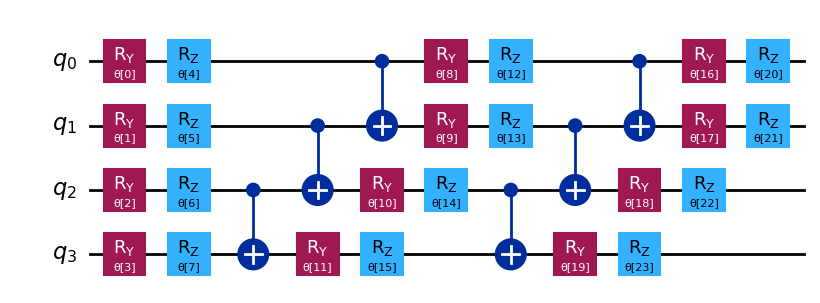


3. CIRCUITO VQC COMPLETO SENZA MISURE:


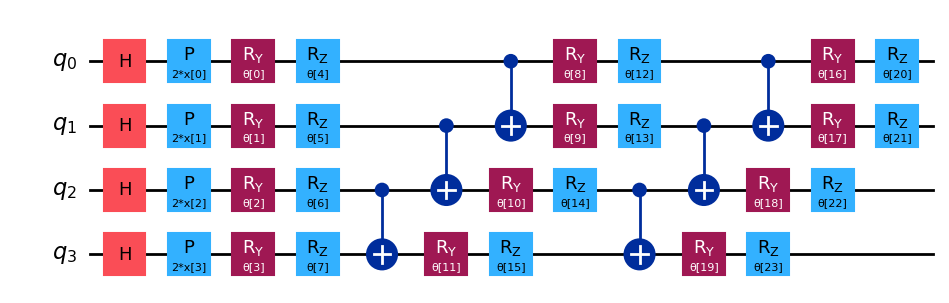


4. CIRCUITO VQC COMPLETO CON MISURE:


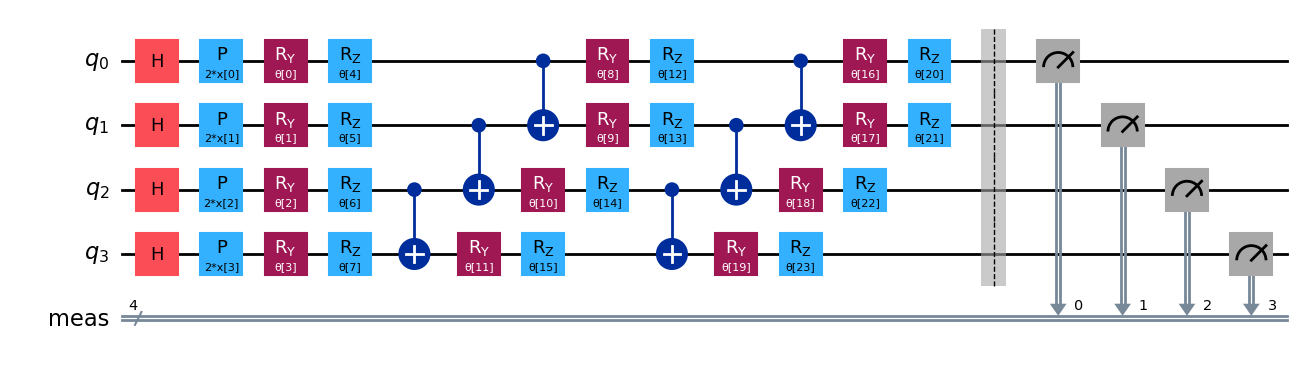


--------------------------------------------------------------------------------
Ottimizzazione con COBYLA - 4 feature
--------------------------------------------------------------------------------
loss_function: 0.687149 valutazione: 1
loss_function: 0.685633 valutazione: 10
loss_function: 0.652721 valutazione: 20
loss_function: 0.626801 valutazione: 30
loss_function: 0.620375 valutazione: 40
loss_function: 0.6442 valutazione: 50
loss_function: 0.591044 valutazione: 60
loss_function: 0.562421 valutazione: 70
loss_function: 0.580302 valutazione: 80
loss_function: 0.559866 valutazione: 90
loss_function: 0.560259 valutazione: 100
loss_function: 0.558901 valutazione: 110
loss_function: 0.557069 valutazione: 120
loss_function: 0.55745 valutazione: 130
loss_function: 0.556361 valutazione: 140
loss_function: 0.556939 valutazione: 150
loss_function: 0.55718 valutazione: 160
loss_function: 0.556439 valutazione: 170
loss_function: 0.556373 valutazione: 180
loss_function: 0.556151 valutazione

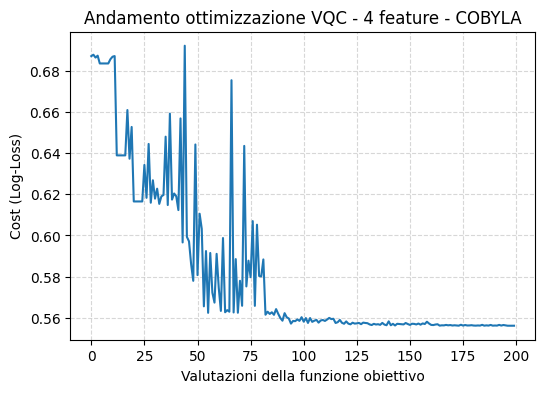


Risultati ideali - VQC con COBYLA - 4 feature
Accuracy: 0.7
              precision    recall  f1-score   support

non promosso       0.60      0.23      0.33        13
    promosso       0.71      0.93      0.81        27

    accuracy                           0.70        40
   macro avg       0.66      0.58      0.57        40
weighted avg       0.68      0.70      0.65        40



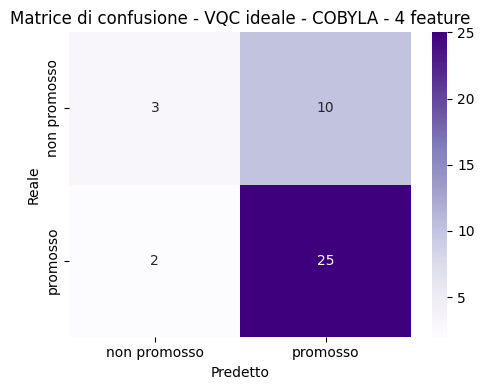


Risultati rumorosi - VQC con COBYLA - 4 feature
Simulatore rumoroso: modello depolarizzante semplificato
Accuracy: 0.725
              precision    recall  f1-score   support

non promosso       0.67      0.31      0.42        13
    promosso       0.74      0.93      0.82        27

    accuracy                           0.72        40
   macro avg       0.70      0.62      0.62        40
weighted avg       0.71      0.72      0.69        40



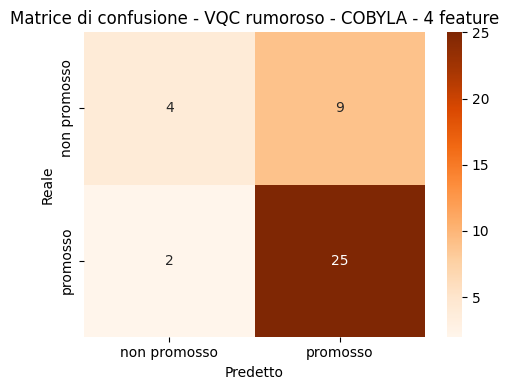


--------------------------------------------------------------------------------
Ottimizzazione con COBYQA - 4 feature
--------------------------------------------------------------------------------
loss_function: 0.687149 valutazione: 1
loss_function: 0.686093 valutazione: 10
loss_function: 0.680038 valutazione: 20
loss_function: 0.687149 valutazione: 30
loss_function: 0.687149 valutazione: 40
loss_function: 0.712109 valutazione: 50
loss_function: 0.628387 valutazione: 60
loss_function: 0.626626 valutazione: 70
loss_function: 0.626548 valutazione: 80
loss_function: 0.628305 valutazione: 90
loss_function: 0.62573 valutazione: 100
loss_function: 0.631471 valutazione: 110
loss_function: 0.627489 valutazione: 120
loss_function: 0.626771 valutazione: 130
loss_function: 0.626348 valutazione: 140
loss_function: 0.626345 valutazione: 150
loss_function: 0.625308 valutazione: 160
loss_function: 0.625164 valutazione: 170
loss_function: 0.625415 valutazione: 180
loss_function: 0.624851 valutazi

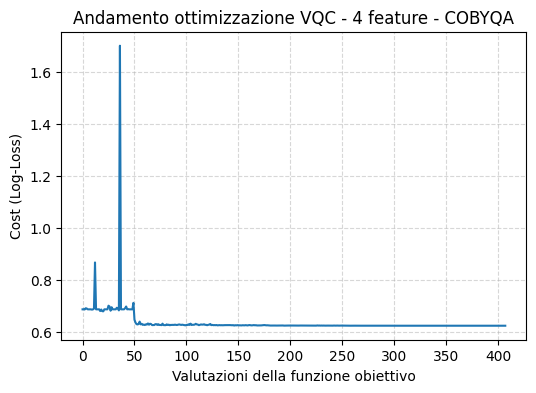


Risultati ideali - VQC con COBYQA - 4 feature
Accuracy: 0.675
              precision    recall  f1-score   support

non promosso       0.00      0.00      0.00        13
    promosso       0.68      1.00      0.81        27

    accuracy                           0.68        40
   macro avg       0.34      0.50      0.40        40
weighted avg       0.46      0.68      0.54        40



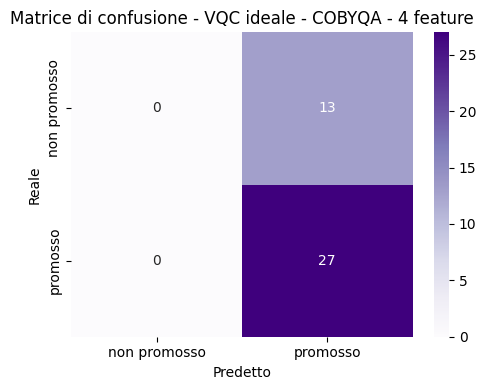


Risultati rumorosi - VQC con COBYQA - 4 feature
Simulatore rumoroso: modello depolarizzante semplificato
Accuracy: 0.675
              precision    recall  f1-score   support

non promosso       0.00      0.00      0.00        13
    promosso       0.68      1.00      0.81        27

    accuracy                           0.68        40
   macro avg       0.34      0.50      0.40        40
weighted avg       0.46      0.68      0.54        40



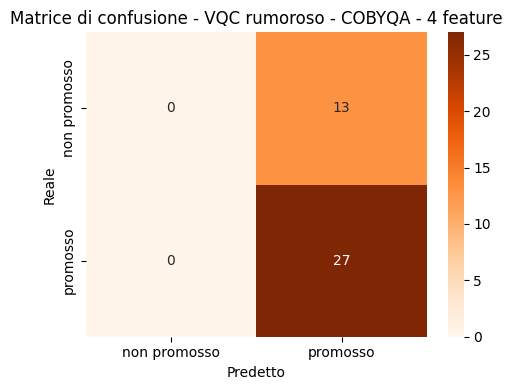

In [12]:
# Parametri sperimentali della parte quantistica
VQC_TRAIN_SIZE = 80
VQC_TEST_SIZE = 40
VQC_MAXITER = 200
VQC_REPS_DEFAULT = 2

quantum_results = []
OPTIMIZERS_TO_TEST = ["COBYLA", "COBYQA"]

for feature_set_name, feature_names in FEATURE_SETS.items():
    num_features = len(feature_names)
    print("\n" + "="*80)
    print(f" VQC - {feature_set_name}: {feature_names} ({num_features} qubit)")
    print("="*80)

    # Dataset parziale: usiamo solo le feature scelte e il target
    X_vqc_raw = student_df[feature_names].copy()
    y_vqc = student_df[TARGET].copy()

    # Split ridotto solo per il VQC, per mantenere tempi compatibili con Colab
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_vqc_raw,
        y_vqc,
        train_size=VQC_TRAIN_SIZE,
        test_size=VQC_TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_vqc,
    )

    # Imputazione e scaling calcolati solo sul training set
    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train_raw),
        columns=feature_names,
        index=X_train_raw.index,
    )
    X_test_imp = pd.DataFrame(
        imputer.transform(X_test_raw),
        columns=feature_names,
        index=X_test_raw.index,
    )

    X_train_scaled, X_test_scaled, scaler = scale_vqc_after_split(X_train_imp, X_test_imp)

    X_train_new = X_train_scaled.values.tolist()
    X_test_new = X_test_scaled.values.tolist()
    y_train_new = y_train.astype(int).tolist()
    y_test_new = y_test.astype(int).tolist()

    print(f"Training VQC: {len(X_train_new)} esempi")
    print(f"Test VQC: {len(X_test_new)} esempi")

    # Costruzione del circuito per N feature/qubit
    feature_map = ZFeatureMap(feature_dimension=num_features, reps=1)
    ansatz = EfficientSU2(num_features, reps=VQC_REPS_DEFAULT)

    vqc_circuit = feature_map.compose(ansatz)
    ad_hoc_circuit = vqc_circuit.copy()
    ad_hoc_circuit.measure_all()

    print(f"\n1. FEATURE MAP - ZFeatureMap ({num_features} qubit):")
    display(feature_map.decompose().draw(output="mpl", fold=20))

    print(f"\n2. ANSATZ - EfficientSU2 ({num_features} qubit):")
    display(ansatz.decompose().draw(output="mpl", fold=20))

    print("\n3. CIRCUITO VQC COMPLETO SENZA MISURE:")
    display(vqc_circuit.decompose().draw(output="mpl", style="iqp", fold=20))

    print("\n4. CIRCUITO VQC COMPLETO CON MISURE:")
    display(ad_hoc_circuit.decompose().draw(output="mpl", style="iqp", fold=20))

    def test_classifier(data, labels, variational, noisy=False):
        if noisy:
            probability = classification_probability_with_noisy(
                data,
                variational,
                feature_map,
                ansatz,
                ad_hoc_circuit,
            )
        else:
            probability = classification_probability(
                data,
                variational,
                feature_map,
                ansatz,
                ad_hoc_circuit,
            )

        predictions = [max(p, key=p.get) for p in probability]
        acc = accuracy_score(labels, predictions)
        return acc, predictions

    for optimizer_name in OPTIMIZERS_TO_TEST:
        print("\n" + "-"*80)
        print(f"Ottimizzazione con {optimizer_name} - {feature_set_name}")
        print("-"*80)

        optimization_log = {
            "costs": [],
            "parameters": [],
        }

        def objective_function(variational):
            cost = cost_function(
                X_train_new,
                y_train_new,
                variational,
                feature_map,
                ansatz,
                ad_hoc_circuit,
            )
            optimization_log["costs"].append(cost)
            optimization_log["parameters"].append(np.array(variational).copy())

            # Stampiamo solo alcune iterazioni per non rendere l'output troppo lungo
            evaluation_number = len(optimization_log["costs"])
            if evaluation_number == 1 or evaluation_number % 10 == 0:
                print("loss_function:", round(cost, 6), "valutazione:", evaluation_number)

            return cost

        initial_point = np.zeros(ansatz.num_parameters)

        try:
            res = minimize(
                objective_function,
                initial_point,
                method=optimizer_name,
                options={"maxiter": VQC_MAXITER},
            )
        except ValueError as exc:
            print(f"{optimizer_name} non disponibile in questa versione di SciPy. Uso Powell come fallback.")
            optimizer_name = "POWELL fallback"
            res = minimize(
                objective_function,
                initial_point,
                method="Powell",
                options={"maxiter": VQC_MAXITER},
            )

        opt_var = res.x

        # Plot della loss per l'ottimizzatore corrente
        plt.figure(figsize=(6, 4))
        plt.plot(optimization_log["costs"])
        plt.xlabel("Valutazioni della funzione obiettivo")
        plt.ylabel("Cost (Log-Loss)")
        plt.title(f"Andamento ottimizzazione VQC - {feature_set_name} - {optimizer_name}")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

        # Valutazione ideale
        acc_ideal, predictions_test_ideal = test_classifier(
            X_test_new,
            y_test_new,
            opt_var,
            noisy=False,
        )

        prec_ideal = precision_score(y_test_new, predictions_test_ideal, zero_division=0)
        rec_ideal = recall_score(y_test_new, predictions_test_ideal, zero_division=0)
        f1_ideal = f1_score(y_test_new, predictions_test_ideal, zero_division=0)

        quantum_results.append({
            "feature_set": feature_set_name,
            "n_feature": num_features,
            "model": f"VQC - {optimizer_name} (ideale)",
            "accuracy": acc_ideal,
            "precision": prec_ideal,
            "recall": rec_ideal,
            "f1_score": f1_ideal,
        })

        print(f"\nRisultati ideali - VQC con {optimizer_name} - {feature_set_name}")
        print("Accuracy:", round(acc_ideal, 4))
        print(classification_report(y_test_new, predictions_test_ideal, target_names=CLASS_NAMES, zero_division=0))

        cm_ideal = confusion_matrix(y_test_new, predictions_test_ideal)
        plt.figure(figsize=(5, 4))
        sns.heatmap(
            cm_ideal,
            annot=True,
            fmt="d",
            cmap="Purples",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
        )
        plt.title(f"Matrice di confusione - VQC ideale - {optimizer_name} - {feature_set_name}")
        plt.xlabel("Predetto")
        plt.ylabel("Reale")
        plt.tight_layout()
        plt.show()

        # Valutazione rumorosa del circuito già ottimizzato
        acc_noisy, predictions_test_noisy = test_classifier(
            X_test_new,
            y_test_new,
            opt_var,
            noisy=True,
        )

        prec_noisy = precision_score(y_test_new, predictions_test_noisy, zero_division=0)
        rec_noisy = recall_score(y_test_new, predictions_test_noisy, zero_division=0)
        f1_noisy = f1_score(y_test_new, predictions_test_noisy, zero_division=0)

        _, simulator_name = get_noisy_simulator()

        quantum_results.append({
            "feature_set": feature_set_name,
            "n_feature": num_features,
            "model": f"VQC - {optimizer_name} (rumore)",
            "accuracy": acc_noisy,
            "precision": prec_noisy,
            "recall": rec_noisy,
            "f1_score": f1_noisy,
        })

        print(f"\nRisultati rumorosi - VQC con {optimizer_name} - {feature_set_name}")
        print("Simulatore rumoroso:", simulator_name)
        print("Accuracy:", round(acc_noisy, 4))
        print(classification_report(y_test_new, predictions_test_noisy, target_names=CLASS_NAMES, zero_division=0))

        cm_noisy = confusion_matrix(y_test_new, predictions_test_noisy)
        plt.figure(figsize=(5, 4))
        sns.heatmap(
            cm_noisy,
            annot=True,
            fmt="d",
            cmap="Oranges",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
        )
        plt.title(f"Matrice di confusione - VQC rumoroso - {optimizer_name} - {feature_set_name}")
        plt.xlabel("Predetto")
        plt.ylabel("Reale")
        plt.tight_layout()
        plt.show()


## 13. Verifica del numero di repliche di EfficientSU2

Per verificare se la qualità del VQC cambia aumentando la profondità dell'ansatz, viene eseguito un esperimento aggiuntivo variando il parametro `reps` di `EfficientSU2`. Il test viene fatto sulla configurazione a 4 feature, usando COBYLA e simulazione ideale, così da isolare l'effetto della profondità del circuito senza aggiungere il rumore.


Esperimento reps EfficientSU2: reps=1


/tmp/ipykernel_1610/3682467530.py:36: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(feature_dimension=num_features, reps=1)
/tmp/ipykernel_1610/3682467530.py:37: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_features, reps=reps_value)


loss_function: 0.687149 valutazione: 1
loss_function: 0.683864 valutazione: 10
loss_function: 0.713105 valutazione: 20
loss_function: 0.632301 valutazione: 30
loss_function: 0.629795 valutazione: 40
loss_function: 0.624851 valutazione: 50
loss_function: 0.624204 valutazione: 60
loss_function: 0.624475 valutazione: 70
loss_function: 0.624489 valutazione: 80
loss_function: 0.624396 valutazione: 90
loss_function: 0.623696 valutazione: 100
loss_function: 0.623713 valutazione: 110
loss_function: 0.623602 valutazione: 120
loss_function: 0.62362 valutazione: 130


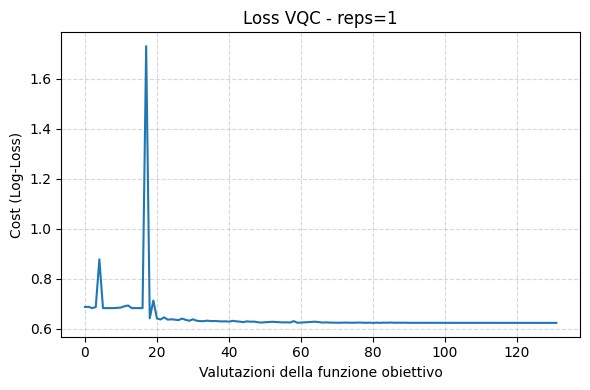


Esperimento reps EfficientSU2: reps=2


/tmp/ipykernel_1610/3682467530.py:36: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(feature_dimension=num_features, reps=1)
/tmp/ipykernel_1610/3682467530.py:37: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_features, reps=reps_value)


loss_function: 0.687149 valutazione: 1
loss_function: 0.685633 valutazione: 10
loss_function: 0.652721 valutazione: 20
loss_function: 0.626801 valutazione: 30
loss_function: 0.620375 valutazione: 40
loss_function: 0.6442 valutazione: 50
loss_function: 0.591044 valutazione: 60
loss_function: 0.562421 valutazione: 70
loss_function: 0.580302 valutazione: 80
loss_function: 0.559866 valutazione: 90
loss_function: 0.560259 valutazione: 100
loss_function: 0.558901 valutazione: 110
loss_function: 0.557069 valutazione: 120
loss_function: 0.55745 valutazione: 130
loss_function: 0.556361 valutazione: 140
loss_function: 0.556939 valutazione: 150
loss_function: 0.55718 valutazione: 160
loss_function: 0.556439 valutazione: 170
loss_function: 0.556373 valutazione: 180
loss_function: 0.556151 valutazione: 190
loss_function: 0.55612 valutazione: 200


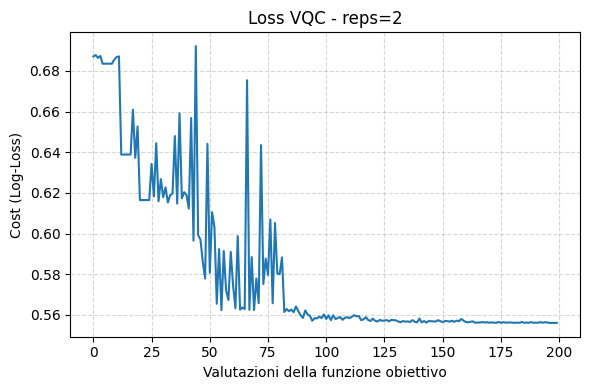


Esperimento reps EfficientSU2: reps=3


/tmp/ipykernel_1610/3682467530.py:36: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(feature_dimension=num_features, reps=1)
/tmp/ipykernel_1610/3682467530.py:37: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_features, reps=reps_value)


loss_function: 0.687149 valutazione: 1
loss_function: 0.678362 valutazione: 10
loss_function: 0.683404 valutazione: 20
loss_function: 0.678362 valutazione: 30
loss_function: 0.673985 valutazione: 40
loss_function: 0.614308 valutazione: 50
loss_function: 0.61681 valutazione: 60
loss_function: 0.616233 valutazione: 70
loss_function: 0.613323 valutazione: 80
loss_function: 0.613263 valutazione: 90
loss_function: 0.611691 valutazione: 100
loss_function: 0.612649 valutazione: 110
loss_function: 0.611907 valutazione: 120
loss_function: 0.612978 valutazione: 130
loss_function: 0.61134 valutazione: 140
loss_function: 0.611083 valutazione: 150
loss_function: 0.611256 valutazione: 160
loss_function: 0.611117 valutazione: 170
loss_function: 0.610842 valutazione: 180
loss_function: 0.611181 valutazione: 190
loss_function: 0.610895 valutazione: 200


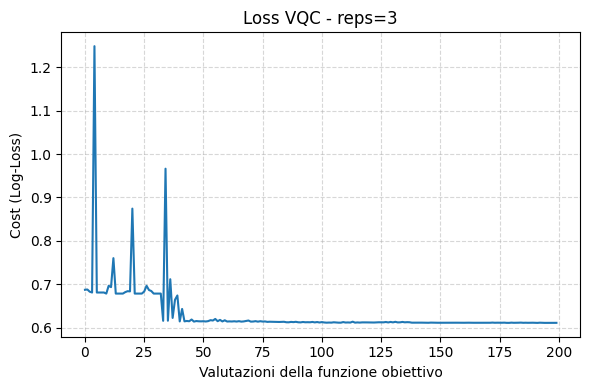

,feature_set,optimizer,reps,n_parameters,n_train,n_test,accuracy,precision,recall,f1_score
0,4 feature,COBYLA,1,16,80,40,0.675,0.675000,1.000000,0.805970
1,4 feature,COBYLA,2,24,80,40,0.700,0.714286,0.925926,0.806452
2,4 feature,COBYLA,3,32,80,40,0.650,0.675676,0.925926,0.781250


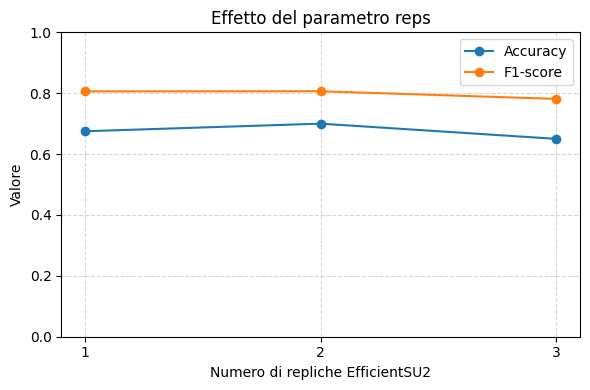

In [13]:
REPS_TO_TEST = [1, 2, 3]
REPS_EXPERIMENT_FEATURE_SET = "4 feature"
REPS_EXPERIMENT_FEATURES = FEATURE_SETS[REPS_EXPERIMENT_FEATURE_SET]
REPS_EXPERIMENT_OPTIMIZER = "COBYLA"

reps_results = []

for reps_value in REPS_TO_TEST:
    print("\n" + "="*80)
    print(f"Esperimento reps EfficientSU2: reps={reps_value}")
    print("="*80)

    num_features = len(REPS_EXPERIMENT_FEATURES)
    X_vqc_raw = student_df[REPS_EXPERIMENT_FEATURES].copy()
    y_vqc = student_df[TARGET].copy()

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_vqc_raw,
        y_vqc,
        train_size=VQC_TRAIN_SIZE,
        test_size=VQC_TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_vqc,
    )

    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=REPS_EXPERIMENT_FEATURES)
    X_test_imp = pd.DataFrame(imputer.transform(X_test_raw), columns=REPS_EXPERIMENT_FEATURES)

    X_train_scaled, X_test_scaled, scaler = scale_vqc_after_split(X_train_imp, X_test_imp)
    X_train_new = X_train_scaled.values.tolist()
    X_test_new = X_test_scaled.values.tolist()
    y_train_new = y_train.astype(int).tolist()
    y_test_new = y_test.astype(int).tolist()

    feature_map = ZFeatureMap(feature_dimension=num_features, reps=1)
    ansatz = EfficientSU2(num_features, reps=reps_value)
    vqc_circuit = feature_map.compose(ansatz)
    ad_hoc_circuit = vqc_circuit.copy()
    ad_hoc_circuit.measure_all()

    optimization_log = {"costs": []}

    def objective_function_reps(variational):
        cost = cost_function(X_train_new, y_train_new, variational, feature_map, ansatz, ad_hoc_circuit)
        optimization_log["costs"].append(cost)
        evaluation_number = len(optimization_log["costs"])
        if evaluation_number == 1 or evaluation_number % 10 == 0:
            print("loss_function:", round(cost, 6), "valutazione:", evaluation_number)
        return cost

    initial_point = np.zeros(ansatz.num_parameters)
    res = minimize(
        objective_function_reps,
        initial_point,
        method=REPS_EXPERIMENT_OPTIMIZER,
        options={"maxiter": VQC_MAXITER},
    )

    opt_var = res.x
    probability = classification_probability(X_test_new, opt_var, feature_map, ansatz, ad_hoc_circuit)
    predictions = [max(p, key=p.get) for p in probability]

    reps_results.append({
        "feature_set": REPS_EXPERIMENT_FEATURE_SET,
        "optimizer": REPS_EXPERIMENT_OPTIMIZER,
        "reps": reps_value,
        "n_parameters": ansatz.num_parameters,
        "n_train": len(X_train_new),
        "n_test": len(X_test_new),
        "accuracy": accuracy_score(y_test_new, predictions),
        "precision": precision_score(y_test_new, predictions, zero_division=0),
        "recall": recall_score(y_test_new, predictions, zero_division=0),
        "f1_score": f1_score(y_test_new, predictions, zero_division=0),
    })

    plt.figure(figsize=(6, 4))
    plt.plot(optimization_log["costs"])
    plt.xlabel("Valutazioni della funzione obiettivo")
    plt.ylabel("Cost (Log-Loss)")
    plt.title(f"Loss VQC - reps={reps_value}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

reps_results_df = pd.DataFrame(reps_results)
display(reps_results_df)

plt.figure(figsize=(6, 4))
plt.plot(reps_results_df["reps"], reps_results_df["accuracy"], marker="o", label="Accuracy")
plt.plot(reps_results_df["reps"], reps_results_df["f1_score"], marker="o", label="F1-score")
plt.xlabel("Numero di repliche EfficientSU2")
plt.ylabel("Valore")
plt.title("Effetto del parametro reps")
plt.ylim(0, 1)
plt.xticks(REPS_TO_TEST)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Tabella riassuntiva finale

In [14]:
quantum_results_df = pd.DataFrame(quantum_results)
final_results_df = pd.concat([classical_results_df, quantum_results_df], ignore_index=True)

print("\n" + "="*80)
print(" CONFRONTO FINALE DELLE PRESTAZIONI (CLASSICO VS QUANTISTICO)")
print("="*80)
display(final_results_df)

print("\nAccuracy a confronto:")
final_accuracy_table = final_results_df.pivot_table(
    index="model",
    columns="feature_set",
    values="accuracy",
)
display(final_accuracy_table)

print("\nF1-score a confronto:")
final_f1_table = final_results_df.pivot_table(
    index="model",
    columns="feature_set",
    values="f1_score",
)
display(final_f1_table)



print("\nRisultati della simulazione rumorosa:")
if "simulation" in quantum_results_df.columns:
    display(quantum_results_df[quantum_results_df["model"].str.contains("rumore")])

print("\nRisultati del test sul parametro reps di EfficientSU2:")
display(reps_results_df)

classical_results_df.to_csv("risultati_classici.csv", index=False)
quantum_results_df.to_csv("risultati_quantistici.csv", index=False)
reps_results_df.to_csv("risultati_reps_efficientSU2.csv", index=False)
final_results_df.to_csv("risultati_completi.csv", index=False)


 CONFRONTO FINALE DELLE PRESTAZIONI (CLASSICO VS QUANTISTICO)


,feature_set,n_feature,model,accuracy,precision,recall,f1_score
0,2 feature,2,Decision Tree,0.672269,0.715789,0.850000,0.777143
1,2 feature,2,Random Forest,0.680672,0.723404,0.850000,0.781609
2,3 feature,3,Decision Tree,0.596639,0.690476,0.725000,0.707317
3,3 feature,3,Random Forest,0.596639,0.695122,0.712500,0.703704
4,4 feature,4,Decision Tree,0.605042,0.689655,0.750000,0.718563
5,4 feature,4,Random Forest,0.655462,0.724138,0.787500,0.754491
6,2 feature,2,VQC - COBYLA (ideale),0.700000,0.727273,0.888889,0.800000
7,2 feature,2,VQC - COBYLA (rumore),0.700000,0.727273,0.888889,0.800000
8,2 feature,2,VQC - COBYQA (ideale),0.700000,0.714286,0.925926,0.806452
9,2 feature,2,VQC - COBYQA (rumore),0.700000,0.714286,0.925926,0.806452



Accuracy a confronto:


feature_set,2 feature,3 feature,4 feature
model,,,
Decision Tree,0.672269,0.596639,0.605042
Random Forest,0.680672,0.596639,0.655462
VQC - COBYLA (ideale),0.700000,0.550000,0.700000
VQC - COBYLA (rumore),0.700000,0.500000,0.725000
VQC - COBYQA (ideale),0.700000,0.675000,0.675000
VQC - COBYQA (rumore),0.700000,0.675000,0.675000



F1-score a confronto:


feature_set,2 feature,3 feature,4 feature
model,,,
Decision Tree,0.777143,0.707317,0.718563
Random Forest,0.781609,0.703704,0.754491
VQC - COBYLA (ideale),0.800000,0.666667,0.806452
VQC - COBYLA (rumore),0.800000,0.629630,0.819672
VQC - COBYQA (ideale),0.806452,0.779661,0.805970
VQC - COBYQA (rumore),0.806452,0.786885,0.805970



Risultati della simulazione rumorosa:

Risultati del test sul parametro reps di EfficientSU2:


,feature_set,optimizer,reps,n_parameters,n_train,n_test,accuracy,precision,recall,f1_score
0,4 feature,COBYLA,1,16,80,40,0.675,0.675000,1.000000,0.805970
1,4 feature,COBYLA,2,24,80,40,0.700,0.714286,0.925926,0.806452
2,4 feature,COBYLA,3,32,80,40,0.650,0.675676,0.925926,0.781250
